# Part 0 - Install and import Libraries

In [1]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install pymupdf openai tqdm

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install pdf2image openai python-dotenv tqdm


Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install PyPDF2 

Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install --upgrade llama-index

Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install torch sentence-transformers

Note: you may need to restart the kernel to use updated packages.


In [7]:
pip install hf_xet

Note: you may need to restart the kernel to use updated packages.


# Part 1 - Loading documents
In this section we will process the documents available and convert them to the markdown format. This includes using LLM to describe images.

In [8]:
import base64
import os
from tqdm import tqdm
from openai import AzureOpenAI
from pdf2image import convert_from_path
from dotenv import load_dotenv
from PyPDF2 import PdfReader
import gc
import os

## Load .env variables

In [9]:
# This reads the .env file and sets the environment variables
load_dotenv()

True

## Client to connect to Azure OpenAI

In [10]:
# Connect to Azure OpenAI
client = AzureOpenAI(
    api_key=os.environ["OPENAI_API_KEY"],
    api_version=os.environ["OPENAI_API_VERSION"],
    azure_endpoint=os.environ["AZURE_OPENAI_ENDPOINT"]
)


## A function to describe images (!!)
This represents the first major change. Instead of only working with watever was extracted from the pdf documents, we will pass an image and a prompt to the LLM and get back the description of the image including all the text and a description of images, tables, graohs, etc. included. The output will be in Markdown format.

In [11]:
# Function to describe an image
def describe_page_image(pil_image):
    # Convert PIL image to base64
    import io
    buffered = io.BytesIO()
    pil_image.save(buffered, format="PNG")
    img_base64 = base64.b64encode(buffered.getvalue()).decode()

    data_url = f"data:image/png;base64,{img_base64}"

    prompt = """
You are a professional technical writer.
Analyze the following page from a PDF document.
Generate a detailed Markdown report that includes:
- Extracted text
- Descriptions of any plots, charts, graphs, or tables
- Any geographic references or maps
Use Markdown syntax cleanly and professionally.
"""

    response = client.chat.completions.create(
        model="gpt-4o",
        messages=[
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt},
                    {"type": "image_url", "image_url": {"url": data_url}}
                ]
            }
        ],
        temperature=0.2
    )
    return response.choices[0].message.content

## From a page to a whole document
The function below splits the passed document into chunks of 60 pages maximum and then process each page one at a time before moving to the next chunk. The results of every page and every chunk are contatenated into one single markdown document. The resulting document is finally stored for future use.
Note that each of the pages is converted into an image, and that image is fed into the function created in the cell above.

In [12]:
# Function to process an entire PDF
def process_pdf_to_markdown(input_pdf_path, output_md_path, dpi=300, pages_per_chunk=60):
    print(f"🔄 Rendering PDF: {input_pdf_path}")

    # Get the total number of pages
    reader = PdfReader(input_pdf_path)
    total_pages = len(reader.pages)

    all_markdown = []

    page_num = 0
    chunk_num = 1

    while page_num < total_pages:
        end_page = min(page_num + pages_per_chunk, total_pages)
        print(f"📚 Processing chunk {chunk_num}: pages {page_num+1} to {end_page}")

        for p in tqdm(range(page_num, end_page), desc=f"Chunk {chunk_num}"):
            pil_image = convert_from_path(
                input_pdf_path,
                dpi=dpi,
                first_page=p + 1,
                last_page=p + 1
            )[0]  # Only one page returned

            page_md = f"\n\n## Page {p + 1}\n\n"

            try:
                page_description = describe_page_image(pil_image)
                page_md += page_description
            except Exception as e:
                page_md += f"_Error processing page {p + 1}: {str(e)}_"

            all_markdown.append(page_md)

            # Immediate memory cleanup
            del pil_image
            gc.collect()

        page_num = end_page
        chunk_num += 1

    # Save final Markdown
    with open(output_md_path, "w", encoding="utf-8") as f:
        f.write("\n\n".join(all_markdown))

## Cycling through the documents in a folder
The documents in the folder are cycled to be converted into markdown.

In [13]:
# Function to run the process for all the files in the folder
def list_files_without_extension(base_path):
    source_path = base_path+"/source_files/"
    md_path = base_path+"/md_files/"

    file_list = os.listdir(source_path)
    
    files_processed = []
    for file_name in file_list:
        if os.path.isfile(os.path.join(source_path, file_name)):
            name, ext = os.path.splitext(file_name)

            input_pdf = source_path + file_name
            output_md = md_path + name + ".md"
            process_pdf_to_markdown(input_pdf, output_md)

            files_processed.append(name)
    return files_processed

In [32]:
base_path = "./data"
cycle_thorug_documents = False  # Currently disabled as this can take close to 2h.

if cycle_thorug_documents:
    htlist_files_without_extension(base_path)

# this will take ~120+ minutes

# Part 2 - Index and ChatBot creation

In [15]:
from llama_index.core import SimpleDirectoryReader
from llama_index.embeddings.azure_openai import AzureOpenAIEmbedding
from llama_index.core import Settings
from llama_index.core import VectorStoreIndex
from llama_index.llms.azure_openai import AzureOpenAI
from llama_index.core.node_parser import SentenceSplitter
from llama_index.core.retrievers import VectorIndexRetriever
from llama_index.core.query_engine import RetrieverQueryEngine
from llama_index.core.postprocessor import SentenceTransformerRerank
from llama_index.core.query_pipeline import QueryPipeline

import ipywidgets as widgets
from IPython.display import display, clear_output
import time

## The indexing (!!)
Again, big changes here. We are creater a better parser where we have much more control on what is happening, including:
* Chunk sizes
* Chunk overlap
* Paragraph separation

After the documents are split, they are embedded using an embedding model and the index is created. 

In [16]:
# Load documents
documents = SimpleDirectoryReader(input_dir="./data/md_files/").load_data(
    show_progress=True
)

# Build a better parser
text_splitter = SentenceSplitter(
    chunk_size=512,   # How big you want each embedded unit
    chunk_overlap=64,  # Small overlap between chunks to preserve context
    paragraph_separator= "\n\n"  # Keeps paragraphs intact better
)

# Parse documents into nice small nodes
nodes = text_splitter.get_nodes_from_documents(documents)

# Then embed
embed_model = AzureOpenAIEmbedding(
    model="text-embedding-3-small",
    api_key=os.environ["OPENAI_API_KEY"],
    api_version=os.environ["OPENAI_API_VERSION"],
    azure_endpoint=os.environ["AZURE_OPENAI_ENDPOINT"]
)
Settings.embed_model = embed_model

# Now build the index over the cleaned nodes
index = VectorStoreIndex(nodes, show_progress=True)

# this will take ~4.5 minutes

Loading files: 100%|███████████████████████████████████████████████████████████████████████████| 6/6 [00:01<00:00,  5.83file/s]


Generating embeddings:   0%|          | 0/884 [00:00<?, ?it/s]

## The Query Engine (!!)
Here we set up our Query Engine including the model we will use. 
* We build a *custom retriever* where we include both: vector search and keyword matching on the index we created beforeand we specify how many initial chunks to retrieve
* We also implement a re-ranker that will select the most fitting chunks retrieved by using an additional Hugging face model.
* We finally create the query engine using the previous steps.

In [17]:
# LLM Setup
llm = AzureOpenAI(
    deployment_name="gpt-4o",
    model="gpt-4o",
    temperature=0.0,
    api_key=os.environ["OPENAI_API_KEY"],
    api_version=os.environ["OPENAI_API_VERSION"],
    azure_endpoint=os.environ["AZURE_OPENAI_ENDPOINT"]
)
Settings.llm = llm

# Build a custom retriever
retriever = VectorIndexRetriever(
    index=index,
    similarity_top_k=10,    # number of results to fetch
    vector_similarity_top_k=10,  # top k for vector search
    hybrid=True            # Enable hybrid retrieving (vector + keyword)
)

# Load a fast, high-quality reranker model from Hugging Face
reranker = SentenceTransformerRerank(
    top_n=5,  # how many reranked chunks to keep
    # model="cross-encoder/ms-marco-MiniLM-L-6-v2"  # small and powerful
    model="cross-encoder/ms-marco-electra-base"    # More powerful but slower
)

# Build the final query engine WITH RERANKER (NOT FORCED)
query_engine = RetrieverQueryEngine.from_args(
    retriever=retriever,
    llm=llm,
    node_postprocessors=[reranker]  # << reranker goes here
)

# # Build the final query engine FORCING THE RERANKER
# query_engine = RetrieverQueryEngine(
#     retriever=retriever,
#     llm=llm,
#     node_postprocessors=[reranker]  # << reranker goes here
# )

# # Query Engine Setup WITHOUT RERANKER
# query_engine = RetrieverQueryEngine.from_args(
#     retriever=retriever,
#     llm=llm   # <-- explicitly pass the llm
# )



## Testing the Query Engine

In [18]:
# Function to get a response
def get_response(user_input):
    return query_engine.query(user_input).response

# Interactive chatbot function
def chatbot():
    output = widgets.Output()
    messages = []  # Save conversation history

    scrollable_chat = widgets.Box(
        [output],
        layout=widgets.Layout(
            width="100%",
            height="400px",
            overflow="auto",
            border="1px solid #ccc",
            padding="5px",
            display="flex",
            flex_flow="column"
        )
    )

    text_box = widgets.Text(
        placeholder="Type your message here",
        description="You:",
        style={'description_width': 'initial'},
        layout=widgets.Layout(width="70%")
    )
    
    submit_button = widgets.Button(
        description="Send",
        button_style="primary",
        layout=widgets.Layout(width="15%")
    )
    
    clear_button = widgets.Button(
        description="Clear Chat",
        button_style="warning",
        layout=widgets.Layout(width="15%")
    )

    button_box = widgets.HBox([text_box, submit_button, clear_button])
    chat_container = widgets.VBox([scrollable_chat, button_box])
    
    def on_submit(_):
        user_message = text_box.value.strip()
        if not user_message:
            return
        
        with output:
            # Display user message
            display(widgets.HTML(
                f"<div style='color: blue; font-weight: bold;'>You:</div> {user_message}"
            ))
        
        try:
            bot_response = get_response(user_message)
            messages.append((user_message, bot_response))  # Save conversation
            
            with output:
                # Streaming simulation (letter-by-letter reveal)
                bot_output = widgets.HTML(value=f"<div style='color: green; font-weight: bold;'>Bot:</div> ")
                display(bot_output)
                full_response = ""
                for char in bot_response:
                    full_response += char
                    bot_output.value = f"<div style='color: green; font-weight: bold;'>Bot:</div> {full_response}"
                    time.sleep(0.005)  # tiny delay for effect

        except Exception as e:
            with output:
                display(widgets.HTML(
                    f"<div style='color: red;'>⚠️ Error: {str(e)}</div>"
                ))
        
        text_box.value = ""
        
    def on_clear(_):
        output.clear_output()
        messages.clear()
    
    # Attach events
    submit_button.on_click(on_submit)
    clear_button.on_click(on_clear)

    display(chat_container)

# Run the chatbot
chatbot()

# How many people in India did Microsoft provide water access to?
# What is the objective of the Carbon Call?

# Part 3 - Let's evaluate the model
In order to be able to evaluate the model, we will use the questions available in our Q&A dataset, retrieve the answer the model produces, and compare them with the reference answers.

In [19]:
from llama_index.core.llama_dataset import LabelledRagDataset
from IPython.display import display, Markdown, clear_output
from ragas.dataset_schema import SingleTurnSample, EvaluationDataset

## Load the Q&A dataset an show some samples

In [33]:
# Load some questions as example
rag_dataset = LabelledRagDataset.from_json("./data/rag_dataset.json")

num_samples = 5
samples = rag_dataset.to_pandas().loc[:num_samples-1, 'query'].values
display(Markdown("\n".join([ "* " + sample for sample in samples])))

* What is the objective of the Carbon Call initiative?
* What are the three key areas that will enable the scale of sustainability solutions?
* How many people in India did Microsoft provide water access to?
* How many people in Indonesia did Microsoft provide water access to?
* How many people in Brazil did Microsoft provide water access to?

In [22]:
rag_dataset.to_pandas().head()

,query,reference_contexts,reference_answer,reference_answer_by,query_by
0,What is the objective of the Carbon Call initi...,"[In February 2022, Microsoft, ClimateWorks Fou...",The objective of Carbon Call is to unify the w...,human,human
1,What are the three key areas that will enable ...,[We will continue\ninvesting in three key area...,1 Advancing AI solutions for greater climate i...,human,human
2,How many people in India did Microsoft provide...,"[Water Table 3\n\nIndia: 309,921\nIndonesia: 2...","309,921",human,human
3,How many people in Indonesia did Microsoft pro...,"[Water Table 3\n\nIndia: 309,921\nIndonesia: 2...","225,389",human,human
4,How many people in Brazil did Microsoft provid...,"[Water Table 3\n\nIndia: 309,921\nIndonesia: 2...","16,408",human,human


## Using the Query Engine
Now, let's calculate the responses for the dataset using the Query Engine

In [23]:
predictions = rag_dataset.make_predictions_with(
    predictor = query_engine,
    show_progress = True
)

# this will take ~6.5 minutes

100%|██████████████████████████████████████████████████████████████████████████████████████████| 10/10 [01:21<00:00,  8.14s/it]


Here is an example of how the dataset is built using the ChatBot

In [24]:
list_of_samples = []

for idx in range(len(rag_dataset.examples)):
    list_of_samples.append(
        SingleTurnSample (
            user_input = rag_dataset.examples[idx].query,
            reference = rag_dataset.examples[idx].reference_answer,
            response = predictions.predictions[idx].response,
            retrieved_contexts = predictions.predictions[idx].contexts
        )
    )

ragas_evaluation_dataset = EvaluationDataset(list_of_samples)
ragas_evaluation_dataset.to_pandas().head()

,user_input,retrieved_contexts,response,reference
0,What is the objective of the Carbon Call initi...,[---\n\n### Key Initiatives \n\n#### **Carbon...,The objective of the Carbon Call initiative is...,The objective of Carbon Call is to unify the w...
1,What are the three key areas that will enable ...,[#### **Sustainability Skills** \nDelivering ...,The three key areas that will enable the scale...,1 Advancing AI solutions for greater climate i...
2,How many people in India did Microsoft provide...,[## Page 34\n\n# Improving Access to Water: De...,"Microsoft provided water access to 309,921 peo...","309,921"
3,How many people in Indonesia did Microsoft pro...,[## Page 34\n\n# Improving Access to Water: De...,"Microsoft provided water access to 225,389 peo...","225,389"
4,How many people in Brazil did Microsoft provid...,[## Page 34\n\n# Improving Access to Water: De...,"Microsoft provided clean water access to 16,40...","16,408"


## Initialize the LLM and Embedding Models for the evaluation

In [25]:
# To calculate the Generative AI quality metrics
from ragas.llms import LlamaIndexLLMWrapper
from ragas.embeddings import LlamaIndexEmbeddingsWrapper
from ragas.evaluation import evaluate
from ragas.run_config import RunConfig

from ragas.metrics import (
    Faithfulness,
    ContextPrecision,
    ContextRecall
)

import pandas as pd

Note that we will use the same `llm` and `embed_model` variables as before.

In [26]:
evaluator_llm = LlamaIndexLLMWrapper(llm)
evaluator_embeddings = LlamaIndexEmbeddingsWrapper(embed_model)

Now, with our pre defined metrics and the ground truth from the Q&A dataset, we will proceed and use RAGAS to evaluate the response

In [27]:
metrics = [
    Faithfulness(llm=evaluator_llm),
    ContextPrecision(llm=evaluator_llm),
    ContextRecall(llm=evaluator_llm)
]
ragas_evaluation_result = evaluate(
    dataset=ragas_evaluation_dataset,
    metrics=metrics,
    llm=evaluator_llm,
    embeddings=evaluator_embeddings,
    run_config=RunConfig(timeout=1800, max_wait=180, max_retries=20),
    show_progress=True,
    batch_size=5
)

# this will take ~6 minutes if S0 quota is not exceeded. Otherwise it will be ~8 to 20m

Evaluating:   0%|          | 0/150 [00:00<?, ?it/s]

Batch 1/30:   0%|          | 0/5 [00:00<?, ?it/s]

Retrying llama_index.llms.openai.base.OpenAI._achat in 1.0 seconds as it raised RateLimitError: Error code: 429 - {'error': {'code': '429', 'message': 'Requests to the ChatCompletions_Create Operation under Azure OpenAI API version 2024-12-01-preview have exceeded token rate limit of your current OpenAI S0 pricing tier. Please retry after 1 second. Please go here: https://aka.ms/oai/quotaincrease if you would like to further increase the default rate limit. For Free Account customers, upgrade to Pay as you Go here: https://aka.ms/429TrialUpgrade.'}}.
Retrying llama_index.llms.openai.base.OpenAI._achat in 1.0 seconds as it raised RateLimitError: Error code: 429 - {'error': {'code': '429', 'message': 'Requests to the ChatCompletions_Create Operation under Azure OpenAI API version 2024-12-01-preview have exceeded token rate limit of your current OpenAI S0 pricing tier. Please retry after 3 seconds. Please go here: https://aka.ms/oai/quotaincrease if you would like to further increase the 

## Finally, let's compare the results

In [28]:
# Load the old and the new results
df_old_dataset = pd.read_json('./test-dataset.json', orient='records')
df_ragas_result = ragas_evaluation_result.to_pandas()

# Compare the results
values_df1 = []
values_df2 = []

for i in range(4,7):
    values_df1.append(df_ragas_result.iloc[:, i].mean())
    values_df2.append(df_old_dataset.iloc[:, i].mean())
    
# Create a table
variable_names = df_old_dataset.columns[4:]

df_results = pd.DataFrame({
    "Variable": variable_names,
    "New results": values_df1,
    "Old results": values_df2
})

# Display it nicely
display(df_results)


,Variable,New results,Old results
0,faithfulness,0.844778,0.805587
1,context_precision,0.487333,0.330000
2,context_recall,0.626333,0.283333


## Create some plots to illustrate the differences

In [29]:
import matplotlib.pyplot as plt

In [30]:
 # Plot the actual vs estimated values for the selected metric

def plot_a_metric(metric, df1, df2):

    plt.figure(figsize=(20,10))
    plt.plot(df1[metric], label='New Value', marker='o', markersize = 10)
    plt.plot(df2[metric], label='Old Value', marker='s')
    
    
    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.title(f'{metric}: New vs Old')
    plt.legend()
    plt.grid(True)
    plt.show()

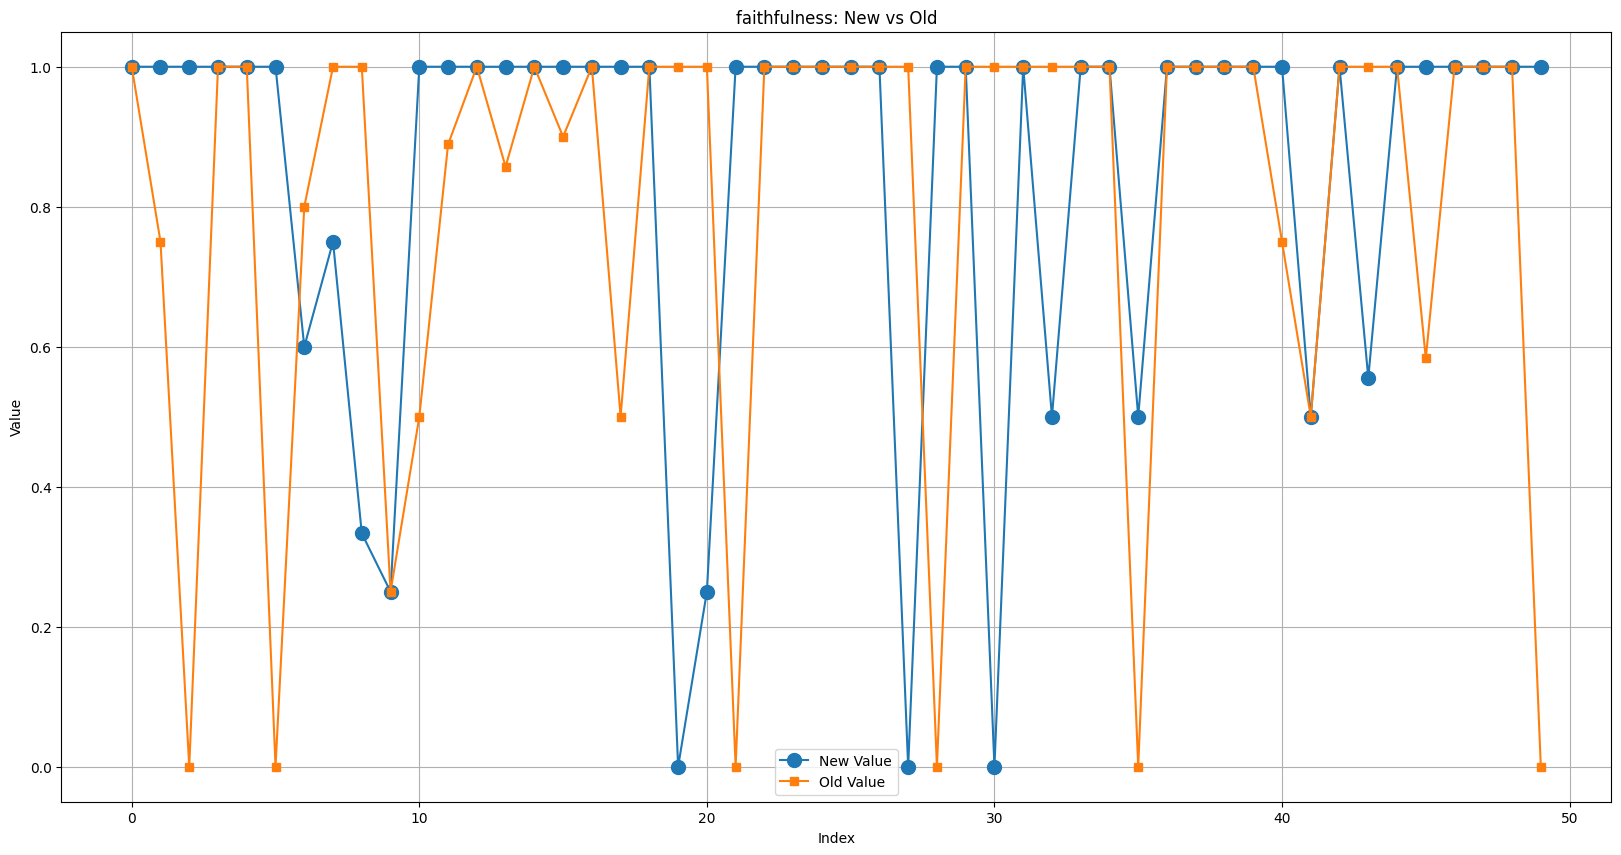

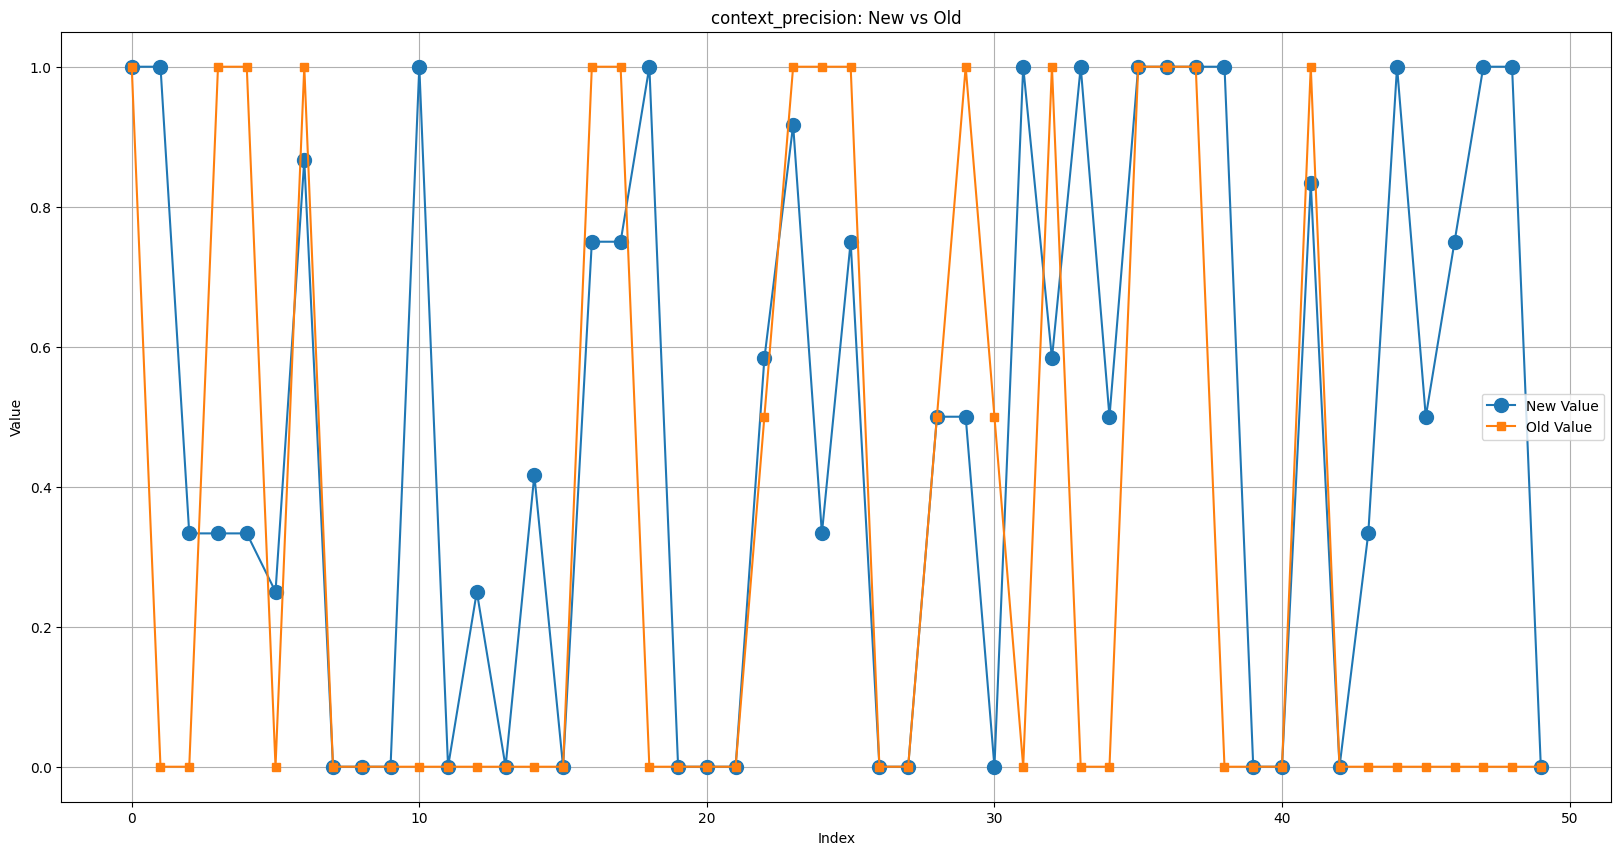

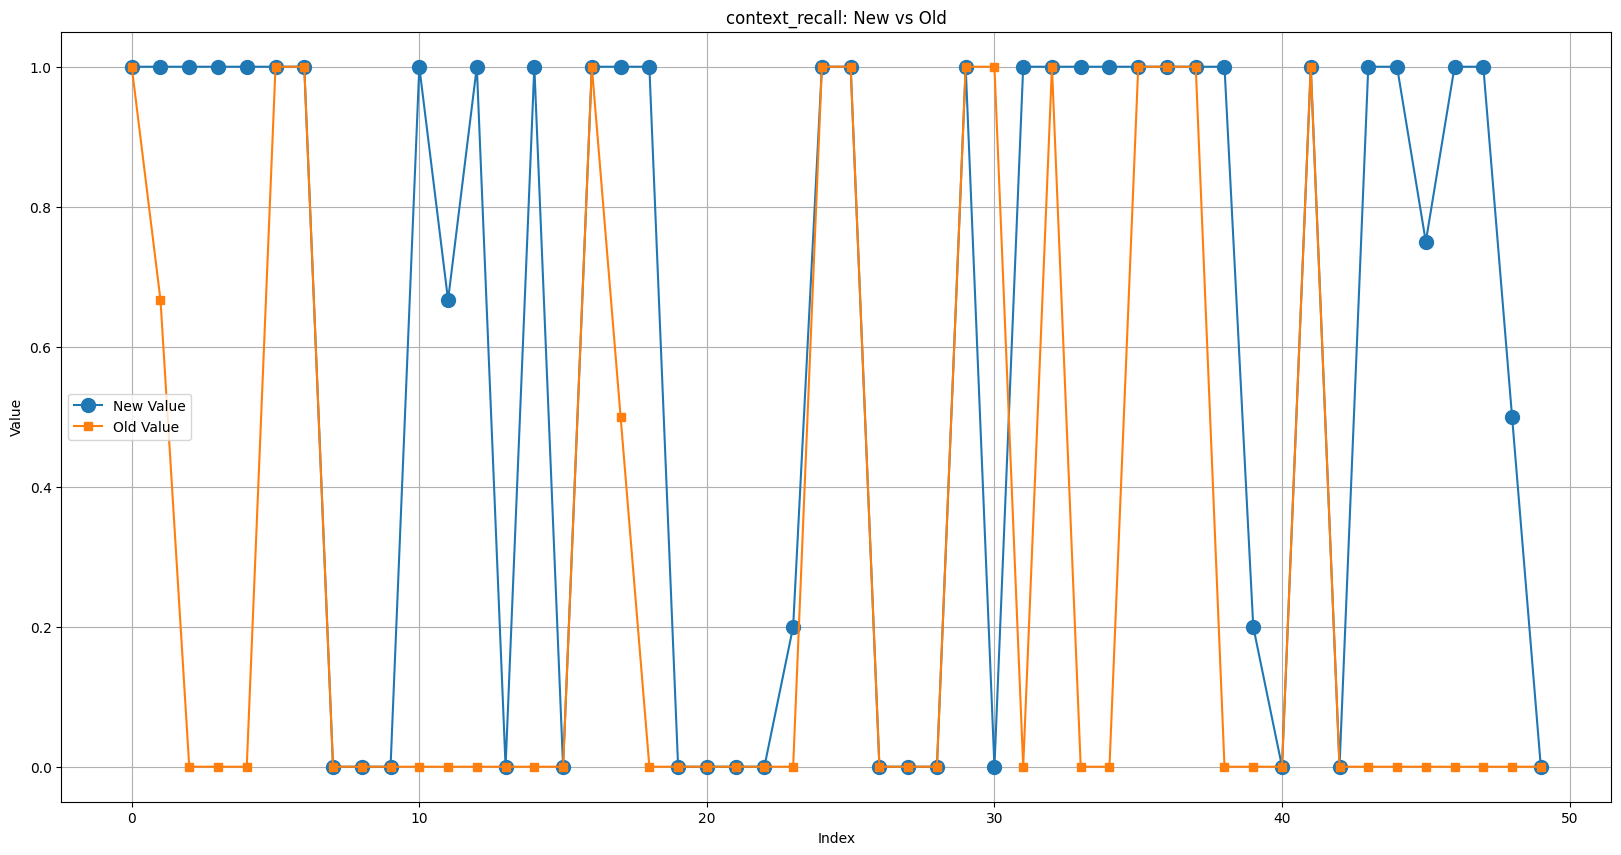

In [31]:
# metric = "context_precision"

for metric in df_old_dataset.columns[4:]:
    plot_a_metric(metric, df_ragas_result, df_old_dataset)